# Week 1 · Lecture 2 — Conjugate Priors

## Learning objectives

1. Define **conjugacy** precisely and explain its computational value.
2. Derive three core conjugate pairs from first principles:
   - Beta–Bernoulli / Beta–Binomial
   - Gamma–Poisson
   - Normal–Normal (known variance) and Normal–Inverse-Gamma (unknown variance)
3. Match each derivation to an empirical sanity check that compares the closed-form posterior against a grid-based brute-force computation.
4. Understand why conjugacy is essentially a property of the **exponential family**, which the next lecture formalises.

## 1. What is conjugacy?

A family of priors $\mathcal{F}$ is **conjugate** to a likelihood $p(\mathcal{D} \mid \theta)$ if, for every prior $p(\theta) \in \mathcal{F}$, the posterior $p(\theta \mid \mathcal{D})$ is also in $\mathcal{F}$.

The practical consequence: posterior inference reduces to *hyperparameter arithmetic*. There is no integral to evaluate.

This is rare. For most likelihood–prior pairs, the posterior has no closed form and we resort to MCMC (Week 3) or variational methods (Week 4). When conjugacy is available, exploit it: even modern probabilistic programs use conjugate updates inside Gibbs samplers and as building blocks for variational families.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, integrate

np.random.seed(0)
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## 2. Beta–Binomial revisited

We covered this in Lecture 1. The key derivation step is

$$
p(\theta \mid \mathcal{D}) \;\propto\; \theta^{k}(1-\theta)^{N-k} \cdot \theta^{\alpha - 1}(1-\theta)^{\beta - 1} \;=\; \theta^{\alpha + k - 1}(1-\theta)^{\beta + N - k - 1}.
$$

So $\theta \mid \mathcal{D} \sim \mathrm{Beta}(\alpha + k,\ \beta + N - k)$. We use this as a baseline to verify our closed-form implementations against grid-based brute force.


In [2]:
def grid_posterior(prior_pdf, log_likelihood_fn, grid):
    # Numerically normalise prior * likelihood on a grid.
    log_prior = np.log(prior_pdf(grid) + 1e-300)
    log_lik   = log_likelihood_fn(grid)
    log_unnorm = log_prior + log_lik
    log_unnorm -= log_unnorm.max()              # stabilise
    unnorm = np.exp(log_unnorm)
    Z = np.trapezoid(unnorm, grid) if hasattr(np, "trapezoid") else np.trapz(unnorm, grid)
    return unnorm / Z


# Test Beta-Binomial closed form against grid
alpha0, beta0 = 2.0, 5.0
N, k = 30, 12
alpha_post, beta_post = alpha0 + k, beta0 + N - k

theta = np.linspace(1e-4, 1 - 1e-4, 2000)
closed_form = stats.beta.pdf(theta, alpha_post, beta_post)
grid_form   = grid_posterior(
    prior_pdf=lambda t: stats.beta.pdf(t, alpha0, beta0),
    log_likelihood_fn=lambda t: k * np.log(t) + (N - k) * np.log(1 - t),
    grid=theta,
)

print(f"max |closed_form - grid|: {np.max(np.abs(closed_form - grid_form)):.2e}")


max |closed_form - grid|: 3.11e-14


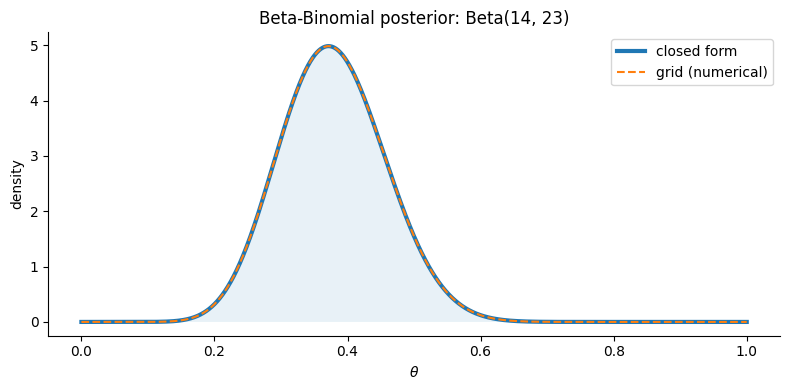

In [3]:
fig, ax = plt.subplots()
ax.plot(theta, closed_form, lw=3, label="closed form")
ax.plot(theta, grid_form, "--", lw=1.5, label="grid (numerical)")
ax.fill_between(theta, 0, closed_form, alpha=0.1)
ax.set_xlabel(r"$\theta$"); ax.set_ylabel("density")
ax.set_title(rf"Beta-Binomial posterior: Beta({alpha_post:.0f}, {beta_post:.0f})")
ax.legend(); plt.tight_layout(); plt.show()


## 3. Gamma–Poisson

Suppose we observe count data $x_1, \dots, x_N \stackrel{\text{iid}}{\sim} \mathrm{Poisson}(\lambda)$. Place a $\mathrm{Gamma}(\alpha, \beta)$ prior on the rate $\lambda$ (in the *shape–rate* parametrisation: density $\propto \lambda^{\alpha - 1} e^{-\beta \lambda}$).

Likelihood:

$$
p(\mathcal{D} \mid \lambda) \;=\; \prod_{i=1}^{N} \frac{\lambda^{x_i} e^{-\lambda}}{x_i!} \;\propto\; \lambda^{\sum x_i}\, e^{-N \lambda}.
$$

Posterior:

$$
p(\lambda \mid \mathcal{D}) \;\propto\; \lambda^{\sum x_i + \alpha - 1}\, e^{-(N + \beta)\, \lambda}
\;=\; \mathrm{Gamma}\!\left(\alpha + \textstyle\sum_i x_i,\ \beta + N\right).
$$

Mnemonic: the prior contributes "$\alpha$ pseudo-counts spread over $\beta$ pseudo-observations", and the data adds the real counts and observations.


Posterior: Gamma(shape=203.0, rate=51.0)
Posterior mean: 3.980    MLE: 4.020    truth: 4.2
max |closed - grid|: 3.39e-12


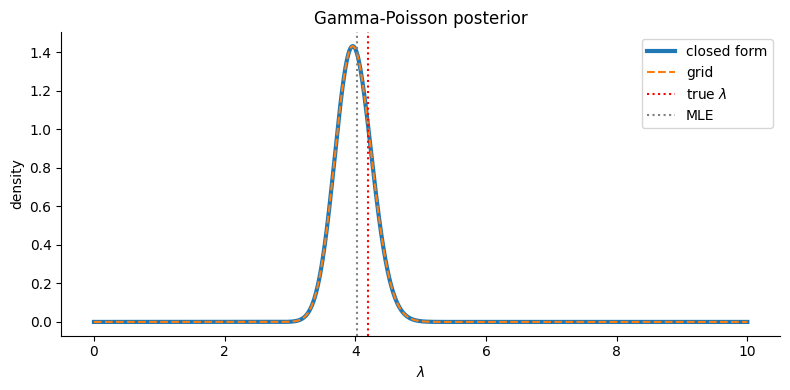

In [4]:
# Simulate Poisson data
true_lambda = 4.2
N = 50
x = stats.poisson.rvs(true_lambda, size=N, random_state=1)

# Prior and posterior
alpha0, beta0 = 2.0, 1.0
alpha_post = alpha0 + x.sum()
beta_post  = beta0 + N

lam = np.linspace(0, 10, 2000)
closed = stats.gamma.pdf(lam, alpha_post, scale=1/beta_post)

grid = grid_posterior(
    prior_pdf=lambda l: stats.gamma.pdf(l, alpha0, scale=1/beta0),
    log_likelihood_fn=lambda l: x.sum() * np.log(l + 1e-12) - N * l,
    grid=lam,
)

print(f"Posterior: Gamma(shape={alpha_post:.1f}, rate={beta_post:.1f})")
print(f"Posterior mean: {alpha_post/beta_post:.3f}    MLE: {x.mean():.3f}    truth: {true_lambda}")
print(f"max |closed - grid|: {np.max(np.abs(closed - grid)):.2e}")

fig, ax = plt.subplots()
ax.plot(lam, closed, lw=3, label="closed form")
ax.plot(lam, grid, "--", lw=1.5, label="grid")
ax.axvline(true_lambda, color="red", ls=":", label="true $\\lambda$")
ax.axvline(x.mean(), color="grey", ls=":", label="MLE")
ax.set_xlabel(r"$\lambda$"); ax.set_ylabel("density")
ax.set_title("Gamma-Poisson posterior")
ax.legend(); plt.tight_layout(); plt.show()


## 4. Normal–Normal (known variance)

Observations: $x_1, \dots, x_N \sim \mathcal{N}(\mu, \sigma^2)$ with $\sigma^2$ *known*. Prior: $\mu \sim \mathcal{N}(\mu_0, \sigma_0^2)$.

Write the log-posterior:

$$
\log p(\mu \mid \mathcal{D}) \;=\; -\frac{1}{2\sigma_0^2}(\mu - \mu_0)^2 \;-\; \frac{1}{2\sigma^2} \sum_i (x_i - \mu)^2 \;+\; \text{const}.
$$

This is a quadratic in $\mu$, so the posterior is Gaussian. Completing the square gives precision-weighted updates:

$$
\sigma_N^2 \;=\; \left(\frac{1}{\sigma_0^2} + \frac{N}{\sigma^2}\right)^{-1}, \qquad
\mu_N \;=\; \sigma_N^2 \left(\frac{\mu_0}{\sigma_0^2} + \frac{\sum_i x_i}{\sigma^2}\right).
$$

The posterior mean is the **precision-weighted average** of the prior mean and the sample mean — a pattern we will see again in evidence approximation (Week 2) and in Kalman filters.


Posterior: N(1.4944, 0.0100)
Posterior std: 0.1000
Sample mean (MLE): 1.4953    truth: 1.5
max |closed - grid|: 1.91e-14


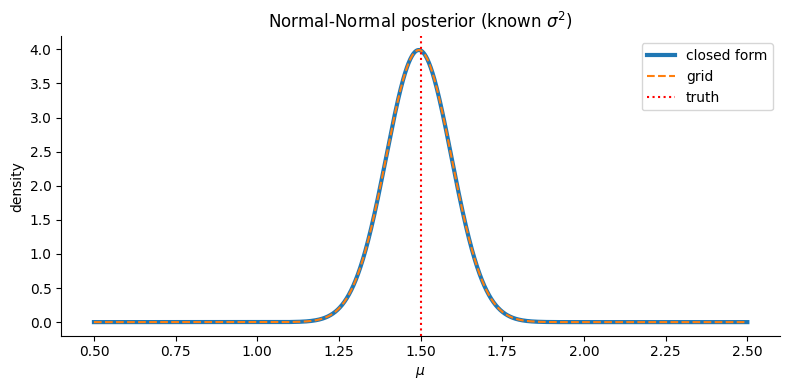

In [5]:
def normal_normal_known_var(x, sigma2, mu0, sigma0_sq):
    N = len(x)
    sigma_N_sq = 1.0 / (1.0 / sigma0_sq + N / sigma2)
    mu_N = sigma_N_sq * (mu0 / sigma0_sq + x.sum() / sigma2)
    return mu_N, sigma_N_sq


# Simulate
true_mu, sigma2 = 1.5, 0.5**2
N = 25
x = np.random.default_rng(2).normal(true_mu, np.sqrt(sigma2), size=N)

mu0, sigma0_sq = 0.0, 4.0**2     # vague prior
mu_N, sigma_N_sq = normal_normal_known_var(x, sigma2, mu0, sigma0_sq)

print(f"Posterior: N({mu_N:.4f}, {sigma_N_sq:.4f})")
print(f"Posterior std: {np.sqrt(sigma_N_sq):.4f}")
print(f"Sample mean (MLE): {x.mean():.4f}    truth: {true_mu}")

mu_grid = np.linspace(true_mu - 1, true_mu + 1, 2000)
closed = stats.norm.pdf(mu_grid, mu_N, np.sqrt(sigma_N_sq))
grid = grid_posterior(
    prior_pdf=lambda m: stats.norm.pdf(m, mu0, np.sqrt(sigma0_sq)),
    log_likelihood_fn=lambda m: -0.5 * np.sum((x[:, None] - m[None, :])**2, axis=0) / sigma2,
    grid=mu_grid,
)
print(f"max |closed - grid|: {np.max(np.abs(closed - grid)):.2e}")

fig, ax = plt.subplots()
ax.plot(mu_grid, closed, lw=3, label="closed form")
ax.plot(mu_grid, grid, "--", lw=1.5, label="grid")
ax.axvline(true_mu, color="red", ls=":", label="truth")
ax.set_xlabel(r"$\mu$"); ax.set_ylabel("density")
ax.set_title("Normal-Normal posterior (known $\\sigma^2$)")
ax.legend(); plt.tight_layout(); plt.show()


## 5. Normal–Inverse-Gamma (unknown variance)

When $\sigma^2$ is also unknown, the conjugate prior on $(\mu, \sigma^2)$ jointly is the **Normal–Inverse-Gamma** (NIG):

$$
\sigma^2 \sim \mathrm{InvGamma}(a_0, b_0), \qquad \mu \mid \sigma^2 \sim \mathcal{N}\!\left(m_0,\ \tfrac{\sigma^2}{\kappa_0}\right).
$$

After observing $\mathcal{D} = \{x_i\}_{i=1}^N$, the posterior is also NIG with parameters

$$
\kappa_N = \kappa_0 + N, \qquad m_N = \frac{\kappa_0 m_0 + N \bar{x}}{\kappa_N},
$$
$$
a_N = a_0 + \tfrac{N}{2}, \qquad b_N = b_0 + \tfrac{1}{2}\sum_i (x_i - \bar{x})^2 + \tfrac{\kappa_0 N (\bar{x} - m_0)^2}{2 \kappa_N}.
$$

Derivation is left as an exercise. Below we implement it and verify by Monte Carlo: simulate from the posterior and check the marginal for $\mu$ is the expected non-standard Student-$t$.


Posterior NIG: m=2.515, kappa=40.010, a=20.500, b=20.235
Posterior E[mu] = 2.515    sample mean = 2.516    truth = 3.0
Posterior E[sigma^2] = 1.038    sample var = 0.985    truth = 1.5


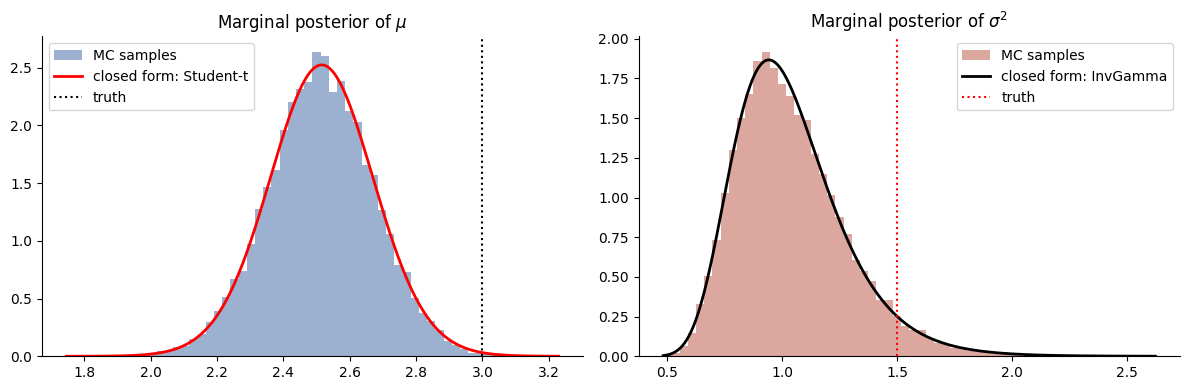

In [6]:
def nig_update(x, m0, kappa0, a0, b0):
    N = len(x)
    xbar = x.mean()
    kappaN = kappa0 + N
    mN = (kappa0 * m0 + N * xbar) / kappaN
    aN = a0 + N / 2
    bN = b0 + 0.5 * np.sum((x - xbar)**2) + 0.5 * kappa0 * N * (xbar - m0)**2 / kappaN
    return mN, kappaN, aN, bN


def sample_nig(m, kappa, a, b, size, rng):
    sigma2 = stats.invgamma.rvs(a, scale=b, size=size, random_state=rng)
    mu = rng.normal(m, np.sqrt(sigma2 / kappa))
    return mu, sigma2


rng = np.random.default_rng(7)
true_mu, true_sigma2 = 3.0, 1.5
N = 40
x = rng.normal(true_mu, np.sqrt(true_sigma2), size=N)

# Vague prior
m0, kappa0, a0, b0 = 0.0, 0.01, 0.5, 0.5
mN, kappaN, aN, bN = nig_update(x, m0, kappa0, a0, b0)
print(f"Posterior NIG: m={mN:.3f}, kappa={kappaN:.3f}, a={aN:.3f}, b={bN:.3f}")
print(f"Posterior E[mu] = {mN:.3f}    sample mean = {x.mean():.3f}    truth = {true_mu}")
print(f"Posterior E[sigma^2] = {bN/(aN-1):.3f}    sample var = {x.var(ddof=0):.3f}    truth = {true_sigma2}")

# Marginal posterior of mu is a non-standard Student-t:
#   mu ~ t_{2a_N}(loc=m_N, scale = sqrt(b_N / (a_N * kappa_N)))
mu_samples, sig2_samples = sample_nig(mN, kappaN, aN, bN, size=20000, rng=rng)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(mu_samples, bins=60, density=True, alpha=0.6, color="#5B7DB1", label="MC samples")
mu_grid = np.linspace(mu_samples.min(), mu_samples.max(), 500)
scale = np.sqrt(bN / (aN * kappaN))
axes[0].plot(mu_grid, stats.t.pdf(mu_grid, df=2*aN, loc=mN, scale=scale),
             "r-", lw=2, label="closed form: Student-t")
axes[0].axvline(true_mu, color="k", ls=":", label="truth")
axes[0].set_title(r"Marginal posterior of $\mu$"); axes[0].legend()

axes[1].hist(sig2_samples, bins=60, density=True, alpha=0.6, color="#C46D5E", label="MC samples")
sig2_grid = np.linspace(sig2_samples.min(), sig2_samples.max(), 500)
axes[1].plot(sig2_grid, stats.invgamma.pdf(sig2_grid, aN, scale=bN),
             "k-", lw=2, label="closed form: InvGamma")
axes[1].axvline(true_sigma2, color="red", ls=":", label="truth")
axes[1].set_title(r"Marginal posterior of $\sigma^2$"); axes[1].legend()

plt.tight_layout(); plt.show()


## 6. Take-aways

- Conjugate priors collapse Bayesian inference to hyperparameter updates.
- Every closed-form posterior we derived matches a brute-force grid computation to machine precision — this kind of cross-check is non-negotiable in serious Bayesian work.
- All three conjugate pairs share structural features: prior hyperparameters act as **pseudo-data**, and data sufficient statistics enter the posterior as the only data-dependent quantities. The next lecture explains why this is no coincidence — it is the signature of the **exponential family**.

## 7. Exercises

**Exercise 1.5.** Derive the posterior of a Dirichlet–Multinomial pair. State the posterior parameters and identify the pseudo-counts in the prior.

**Exercise 1.6.** For the Normal-NIG model, sample $(\mu, \sigma^2)$ pairs from the posterior, then derive and verify the marginal of $\sigma^2$ analytically.

**Exercise 1.7.** A *vague* (improper) prior is the limit of a conjugate prior as hyperparameters go to zero. Take this limit carefully in the Beta-Binomial case ($\alpha, \beta \to 0$). When does the limiting "posterior" remain proper?

**Exercise 1.8 (Computational).** Implement an online Gamma-Poisson updater that consumes one observation at a time and verify it gives identical results to a batch update on synthetic data of length 1000.
